# Portfolio Project: SpaceX Falcon 9 First-Stage Landing Prediction
## 08 — Classification, Robust Validation, and Temporal Generalization

**Portfolio Project | Business Analytics & Data Analytics**

This notebook is the **predictive-analysis** stage of the SpaceX portfolio. It models four classifier — **Logistic Regression, Support Vector Machine (SVM), Decision Tree, and K-Nearest Neighbors (KNN)**.

**Question:**
> **How stable, class-balanced, and temporally generalizable are the competing models?**

**Primary conclusion preview.** 

SVM has the strongest average accuracy/F1/ROC-AUC under repeated nested validation, while the Decision Tree has the strongest average balanced accuracy and failure recall. However, temporal validation shows that later missions are heavily success-dominated and that even high accuracy can conceal weak failure detection.

## 1. Load the target and engineered features

The analytical flow follows the preceding portfolio notebooks:

- `dataset_part_2_portfolio.csv` supplies the binary `Class` target and launch dates.
- `dataset_part3_portfolio.csv` supplies the numeric feature matrix created in Notebook 05.

Row order is preserved across the two files, matching the original capstone workflow.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    TimeSeriesSplit,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

DATA_PATH = Path("dataset_part_2_portfolio.csv")
FEATURE_PATH = Path("dataset_part3_portfolio.csv")
SUMMARY_OUTPUT_PATH = Path("08_model_performance_summary.csv")

for path in [DATA_PATH, FEATURE_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"{path} was not found beside this notebook.")

data = pd.read_csv(DATA_PATH)
X = pd.read_csv(FEATURE_PATH)

data["Date"] = pd.to_datetime(data["Date"], errors="raise")
y = data["Class"].astype(int).to_numpy()

print(f"Target dataset: {data.shape}")
print(f"Feature matrix: {X.shape}")

Target dataset: (90, 18)
Feature matrix: (90, 81)


## 2. Alignment and data-quality audit

Before modeling, the target and feature files are checked for row alignment, missing values, duplicated feature rows, and class balance.

In [2]:
if len(data) != len(X):
    raise ValueError("Target and feature datasets do not contain the same number of rows.")

if X.isna().any().any():
    raise ValueError("The feature matrix contains missing values.")

audit = pd.Series({
    "observations": len(data),
    "features": X.shape[1],
    "failures_class_0": int((y == 0).sum()),
    "successes_class_1": int((y == 1).sum()),
    "success_share": round(float(y.mean()), 4),
    "duplicate_feature_rows": int(X.duplicated().sum()),
    "first_launch_date": data["Date"].min().date(),
    "last_launch_date": data["Date"].max().date(),
}, name="value")

audit.to_frame()

,value
observations,90
features,81
failures_class_0,30
successes_class_1,60
success_share,0.6667
duplicate_feature_rows,0
first_launch_date,2010-06-04
last_launch_date,2020-11-05


The sample contains **90 missions: 60 successes and 30 failures/no-success outcomes**. A majority-class classifier that always predicts success would therefore achieve **66.7% accuracy** without learning any mission characteristics. This is why accuracy alone is insufficient.

## 3. Model definitions and leakage-safe pipelines

Scaling is required for Logistic Regression, SVM, and KNN, but not for the Decision Tree. The notebook places `StandardScaler` inside each relevant pipeline, so scaling parameters are learned only from the training data within each validation fold.

Hyperparameters are selected using **balanced accuracy**, which gives equal weight to success and failure recall.

In [3]:
models = {
    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000,
                solver="liblinear",
                random_state=42,
            )),
        ]),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"],
        },
    ),
    "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=42)),
        ]),
        {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf", "sigmoid"],
            "model__gamma": ["scale", "auto"],
        },
    ),
    "Decision Tree": (
        Pipeline([
            ("model", DecisionTreeClassifier(random_state=42)),
        ]),
        {
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [2, 3, 4, 5, None],
            "model__min_samples_leaf": [1, 2, 4],
        },
    ),
    "KNN": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()),
        ]),
        {
            "model__n_neighbors": [3, 5, 7, 9, 11, 13],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    ),
}

inner_cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42,
)

list(models.keys())

['Logistic Regression', 'SVM', 'Decision Tree', 'KNN']

## 4. Evaluation metrics

`Class = 1` denotes a successful landing. In addition to conventional success-oriented metrics, this notebook reports **failure recall / specificity**:

Failure Recall = TN / (TN + FP)

This measures the proportion of actual failures correctly identified. It is particularly important because a model can achieve high accuracy by predicting the majority success class while missing many failures.

In [4]:
def evaluate_predictions(y_true, y_pred, y_score=None):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Failure Recall / Specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "Success Recall": tp / (tp + fn) if (tp + fn) else np.nan,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        result["ROC AUC"] = roc_auc_score(y_true, y_score)

    return result


def predicted_scores(estimator, X_eval):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_eval)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X_eval)
    return None

## 5. 80/20 Train Test Split

We define the test size proportion as 20%:

```python
test_size=0.2, random_state=2
```

This produces only **18 test observations**. The portfolio then uses leakage-safe pipelines and balanced-accuracy tuning later on.

This section is a **benchmark**, not the primary basis for selecting a model.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
)

print(f"Training observations: {len(y_train)}")
print(f"Test observations: {len(y_test)}")
print("Test class counts:", dict(zip(*np.unique(y_test, return_counts=True))))

Training observations: 72
Test observations: 18
Test class counts: {np.int64(0): np.int64(6), np.int64(1): np.int64(12)}


In [6]:
holdout_rows = []
holdout_estimators = {}

for model_name, (pipeline, param_grid) in models.items():
    search = GridSearchCV(
        estimator=clone(pipeline),
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="balanced_accuracy",
        n_jobs=1,
    )
    search.fit(X_train, y_train)

    pred = search.predict(X_test)
    score = predicted_scores(search.best_estimator_, X_test)
    metrics = evaluate_predictions(y_test, pred, score)

    holdout_estimators[model_name] = search.best_estimator_
    holdout_rows.append({
        "Model": model_name,
        **metrics,
        "Best Parameters": str(search.best_params_),
    })

holdout_results = pd.DataFrame(holdout_rows).set_index("Model")
holdout_results.round(3)

,Accuracy,Balanced Accuracy,Failure Recall / Specificity,Success Recall,Precision,F1,ROC AUC,Best Parameters
Model,,,,,,,,
Logistic Regression,0.833,0.750,0.500,1.000,0.800,0.889,0.688,"{'model__C': 10, 'model__penalty': 'l1'}"
SVM,0.833,0.750,0.500,1.000,0.800,0.889,0.931,"{'model__C': 10, 'model__gamma': 'scale', 'mod..."
Decision Tree,0.833,0.833,0.833,0.833,0.909,0.870,0.896,"{'model__criterion': 'gini', 'model__max_depth..."
KNN,0.833,0.750,0.500,1.000,0.800,0.889,0.903,"{'model__n_neighbors': 11, 'model__p': 1, 'mod..."


### Interpretation of the 18-observation holdout

- All four models achieve **83.33% accuracy**.
- Logistic Regression, SVM, and KNN classify all 12 successes correctly but identify only 3 of the 6 failures.
- The Decision Tree also reaches 83.33% accuracy, but identifies **5 of 6 failures** while missing 2 successes.

Therefore, equal accuracy does **not** imply equivalent classification behavior. Balanced accuracy and failure recall reveal differences.

### 5.1 Confusion Matrices

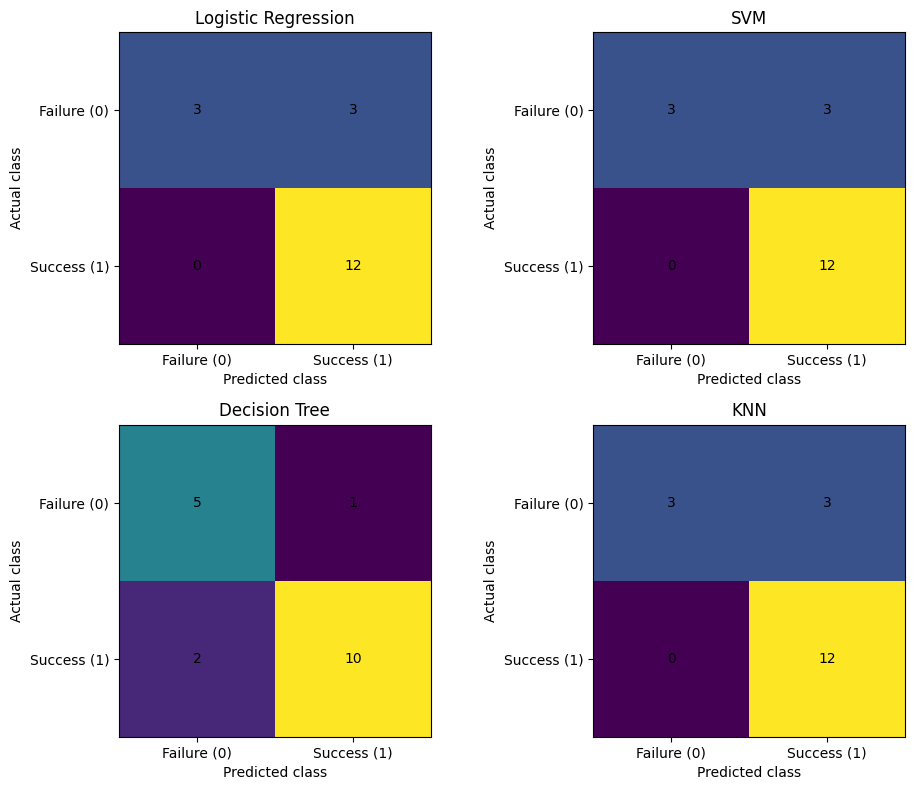

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (model_name, estimator) in zip(axes, holdout_estimators.items()):
    pred = estimator.predict(X_test)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])

    image = ax.imshow(cm)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_xticks([0, 1], ["Failure (0)", "Success (1)"])
    ax.set_yticks([0, 1], ["Failure (0)", "Success (1)"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 6. Majority-Class Baseline

Because 66.7% of the missions are successes, a naïve classifier that always predicts `Class = 1` achieves 66.7% accuracy. Its balanced accuracy and ROC-AUC are 0.50, representing chance-level class discrimination.

In [8]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X, y)
baseline_pred = baseline.predict(X)

baseline_metrics = evaluate_predictions(
    y,
    baseline_pred,
    baseline.predict_proba(X)[:, 1],
)

pd.DataFrame(
    [baseline_metrics],
    index=["Majority-class baseline"],
).round(3)

,Accuracy,Balanced Accuracy,Failure Recall / Specificity,Success Recall,Precision,F1,ROC AUC
Majority-class baseline,0.667,0.5,0.0,1.0,0.667,0.8,0.5


## 7. Primary Model Comparison — Repeated Nested Stratified Cross-Validation

A single 18-row test set is too unstable to support a strong model-selection claim. To extend our model evaluation, the primary comparison therefore uses **nested cross-validation**:

- **Outer loop:** 5-fold stratified CV repeated 5 times → **25 out-of-sample evaluations per model**.
- **Inner loop:** 4-fold stratified CV for hyperparameter selection.
- **Selection metric:** balanced accuracy.

The outer test folds are never used for hyperparameter selection. This substantially reduces the optimistic bias that can occur when tuning and evaluating on the same resampling loop.

In [9]:
outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42,
)

nested_rows = []

for model_name, (pipeline, param_grid) in models.items():
    for fold_number, (train_idx, test_idx) in enumerate(
        outer_cv.split(X, y),
        start=1,
    ):
        search = GridSearchCV(
            estimator=clone(pipeline),
            param_grid=param_grid,
            cv=inner_cv,
            scoring="balanced_accuracy",
            n_jobs=1,
        )

        search.fit(X.iloc[train_idx], y[train_idx])

        pred = search.predict(X.iloc[test_idx])
        score = predicted_scores(
            search.best_estimator_,
            X.iloc[test_idx],
        )

        metrics = evaluate_predictions(
            y[test_idx],
            pred,
            score,
        )

        nested_rows.append({
            "Model": model_name,
            "Outer Fold": fold_number,
            **metrics,
            "Best Parameters": str(search.best_params_),
        })

nested_results = pd.DataFrame(nested_rows)

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Failure Recall / Specificity",
    "Success Recall",
    "Precision",
    "F1",
    "ROC AUC",
]

nested_mean = (
    nested_results.groupby("Model")[metric_columns]
    .mean()
    .sort_values("Balanced Accuracy", ascending=False)
)

nested_std = (
    nested_results.groupby("Model")[metric_columns]
    .std()
    .loc[nested_mean.index]
)

nested_mean.round(3)

,Accuracy,Balanced Accuracy,Failure Recall / Specificity,Success Recall,Precision,F1,ROC AUC
Model,,,,,,,
Decision Tree,0.829,0.800,0.713,0.887,0.871,0.873,0.846
SVM,0.838,0.792,0.653,0.930,0.847,0.884,0.878
Logistic Regression,0.807,0.767,0.647,0.887,0.841,0.858,0.864
KNN,0.800,0.737,0.547,0.927,0.810,0.861,0.834


### 7.1 Variability Across Repeated Outer Folds

Means alone can again hide instability, so the standard deviation across the 25 outer evaluations is reported separately.

In [10]:
nested_std.round(3)

,Accuracy,Balanced Accuracy,Failure Recall / Specificity,Success Recall,Precision,F1,ROC AUC
Model,,,,,,,
Decision Tree,0.060,0.082,0.201,0.096,0.076,0.046,0.106
SVM,0.073,0.090,0.166,0.075,0.063,0.054,0.098
Logistic Regression,0.058,0.075,0.176,0.090,0.062,0.044,0.083
KNN,0.058,0.085,0.190,0.065,0.063,0.038,0.110


### Nested-CV interpretation

The repeated nested results show that the models are **similar but not identical**:

- **SVM** has the highest mean accuracy (**0.838**), F1 (**0.884**), success recall (**0.930**), and ROC-AUC (**0.878**).
- **Decision Tree** has the highest mean balanced accuracy (**0.800**) and the strongest failure recall/specificity (**0.713**).
- Logistic Regression provides competitive ROC-AUC (**0.864**) with mean balanced accuracy of **0.767**.
- KNN has the weakest mean balanced accuracy (**0.737**) and failure recall (**0.547**), despite high success recall (**0.927**).

The differences are modest relative to the observed fold-to-fold variability. For example, balanced-accuracy standard deviations range from roughly **0.075 to 0.090**. It would therefore be too strong to claim that one classifier decisively dominates the others.

The more defensible conclusion is:

> **SVM provides the strongest average overall discrimination, while the Decision Tree provides the strongest class-balanced performance and failure detection.**

### 7.2 Visual Comparison of Mean Cross-Validated Performance

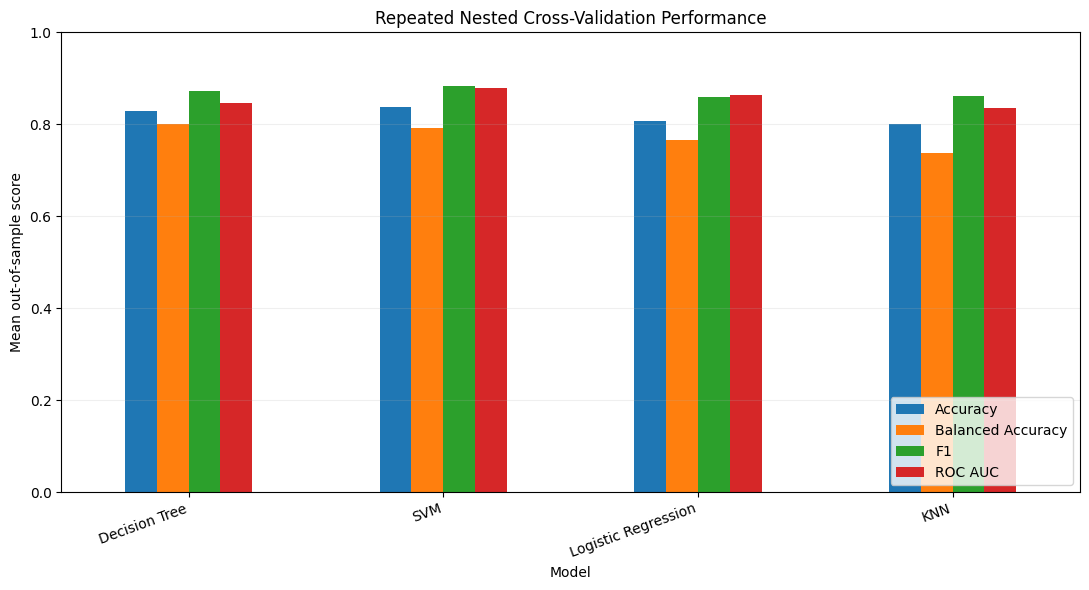

In [11]:
comparison_plot = nested_mean[
    ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC"]
].copy()

ax = comparison_plot.plot(
    kind="bar",
    figsize=(11, 6),
)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Mean out-of-sample score")
ax.set_xlabel("Model")
ax.set_title("Repeated Nested Cross-Validation Performance")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 8. Temporal Holdout — Can Earlier Missions Predict Later Missions?

Notebook 05 showed a strong long-run improvement in landing success. That means the data-generating process is not obviously stationary: early experimental missions and later mature missions differ systematically.

To test temporal generalization, the observations are sorted by launch date:

- **Training:** earliest 72 missions (80%).
- **Test:** latest 18 missions (20%), from **2020-01-19 through 2020-11-05**.

Hyperparameters are selected only within the earlier training period using an expanding `TimeSeriesSplit`. The final 18 missions remain completely untouched until evaluation.

In [12]:
date_order = np.argsort(data["Date"].to_numpy())

X_time = X.iloc[date_order].reset_index(drop=True)
y_time = y[date_order]
dates_time = data["Date"].iloc[date_order].reset_index(drop=True)

temporal_cut = int(len(X_time) * 0.8)

X_train_time = X_time.iloc[:temporal_cut]
X_test_time = X_time.iloc[temporal_cut:]
y_train_time = y_time[:temporal_cut]
y_test_time = y_time[temporal_cut:]

print(
    "Training period:",
    dates_time.iloc[0].date(),
    "to",
    dates_time.iloc[temporal_cut - 1].date(),
)
print(
    "Test period:",
    dates_time.iloc[temporal_cut].date(),
    "to",
    dates_time.iloc[-1].date(),
)
print("Temporal test class counts:", dict(zip(*np.unique(y_test_time, return_counts=True))))

Training period: 2010-06-04 to 2020-01-07
Test period: 2020-01-19 to 2020-11-05
Temporal test class counts: {np.int64(0): np.int64(3), np.int64(1): np.int64(15)}


The later holdout contains **15 successes and only 3 failures**. As a result, simply predicting success for every mission already yields **83.33% accuracy**. This is exactly why balanced accuracy and failure recall are essential for interpreting the temporal experiment.

In [13]:
time_cv = TimeSeriesSplit(n_splits=4)

temporal_rows = []
temporal_estimators = {}

for model_name, (pipeline, param_grid) in models.items():
    search = GridSearchCV(
        estimator=clone(pipeline),
        param_grid=param_grid,
        cv=time_cv,
        scoring="balanced_accuracy",
        n_jobs=1,
        error_score=np.nan,
    )

    search.fit(X_train_time, y_train_time)

    pred = search.predict(X_test_time)
    score = predicted_scores(
        search.best_estimator_,
        X_test_time,
    )

    metrics = evaluate_predictions(
        y_test_time,
        pred,
        score,
    )

    temporal_estimators[model_name] = search.best_estimator_
    temporal_rows.append({
        "Model": model_name,
        **metrics,
        "Best Parameters": str(search.best_params_),
    })

# Majority-class benchmark for the same temporal holdout.
temporal_dummy = DummyClassifier(strategy="most_frequent")
temporal_dummy.fit(X_train_time, y_train_time)
dummy_pred = temporal_dummy.predict(X_test_time)
dummy_score = temporal_dummy.predict_proba(X_test_time)[:, 1]

temporal_rows.append({
    "Model": "Majority Baseline",
    **evaluate_predictions(y_test_time, dummy_pred, dummy_score),
    "Best Parameters": "Always predict training majority class",
})

temporal_results = (
    pd.DataFrame(temporal_rows)
    .set_index("Model")
)

temporal_results.round(3)

,Accuracy,Balanced Accuracy,Failure Recall / Specificity,Success Recall,Precision,F1,ROC AUC,Best Parameters
Model,,,,,,,,
Logistic Regression,0.889,0.667,0.333,1.0,0.882,0.938,0.589,"{'model__C': 1, 'model__penalty': 'l1'}"
SVM,0.889,0.667,0.333,1.0,0.882,0.938,0.533,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo..."
Decision Tree,0.889,0.667,0.333,1.0,0.882,0.938,0.667,"{'model__criterion': 'gini', 'model__max_depth..."
KNN,0.833,0.500,0.000,1.0,0.833,0.909,0.589,"{'model__n_neighbors': 13, 'model__p': 1, 'mod..."
Majority Baseline,0.833,0.500,0.000,1.0,0.833,0.909,0.500,Always predict training majority class


### Temporal Interpretation

Logistic Regression, SVM, and Decision Tree each achieve **88.89% accuracy**, apparently outperforming the majority baseline at **83.33%**. However, their balanced accuracy is only **0.667**.

Their common temporal confusion pattern is:

- **15/15 later successes correctly predicted**
- **1/3 later failures correctly predicted**
- **2/3 later failures incorrectly predicted as successes**

KNN predicts every later mission as a success, producing **83.33% accuracy but only 0.50 balanced accuracy**, exactly matching the majority baseline on class discrimination.

This temporal experiment is one of the most important findings in the project:

> **High accuracy on later missions is partly driven by the dominance of successful landings in the mature 2020 period. The models remain much weaker at identifying the relatively rare failures.**

Therefore, the 88.9% temporal accuracy should **not** be presented as evidence of near-perfect generalization.

### 8.1 Temporal Confusion Matrices

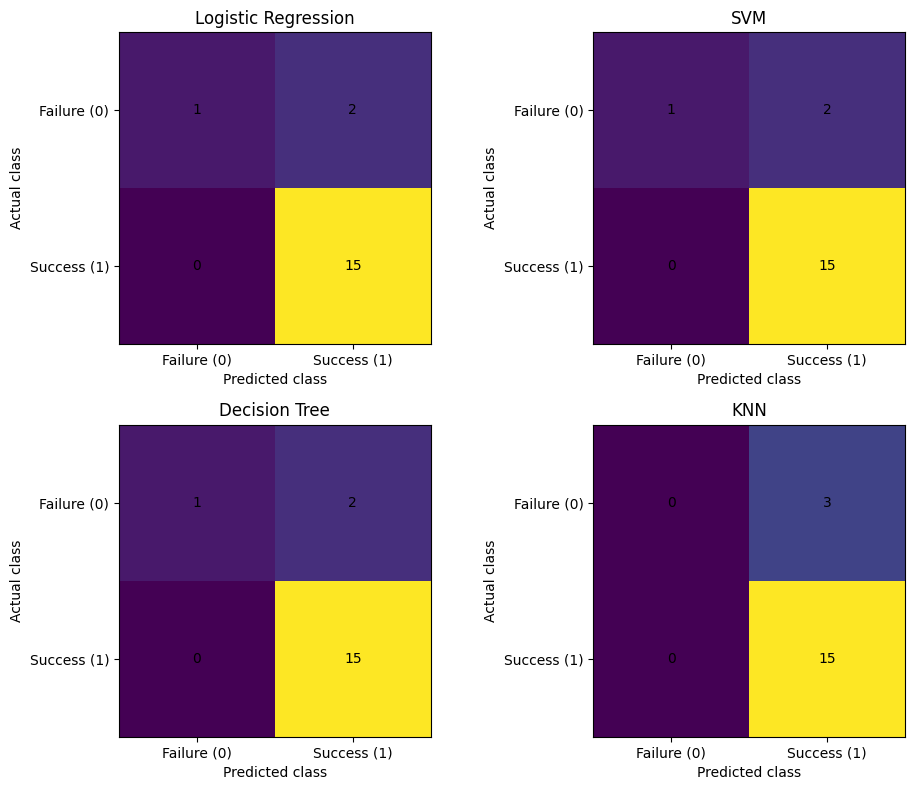

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (model_name, estimator) in zip(axes, temporal_estimators.items()):
    pred = estimator.predict(X_test_time)
    cm = confusion_matrix(
        y_test_time,
        pred,
        labels=[0, 1],
    )

    ax.imshow(cm)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_xticks([0, 1], ["Failure (0)", "Success (1)"])
    ax.set_yticks([0, 1], ["Failure (0)", "Success (1)"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 9. Interpretable Feature Signals

Predictive importance is not causal importance, but interpretable models can help identify which engineered variables are associated with the classification boundary.

The models below are tuned on the full historical sample using stratified cross-validation **only for interpretation after the evaluation experiments have been completed**. Their coefficients/importances are not used to claim new test performance.

### 9.1 Logistic Regression Coefficients

Because the numeric inputs are standardized inside the pipeline, coefficient magnitudes can be compared more meaningfully than in the raw feature scale. Positive coefficients shift predictions toward success; negative coefficients shift them toward failure.

In [15]:
logistic_pipeline, logistic_grid = models["Logistic Regression"]

logistic_search = GridSearchCV(
    estimator=clone(logistic_pipeline),
    param_grid=logistic_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="balanced_accuracy",
    n_jobs=1,
)
logistic_search.fit(X, y)

logistic_coef = logistic_search.best_estimator_.named_steps["model"].coef_[0]

logistic_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": logistic_coef,
        "Absolute Coefficient": np.abs(logistic_coef),
    })
    .sort_values("Absolute Coefficient", ascending=False)
    .head(12)
)

print("Best full-sample logistic parameters:", logistic_search.best_params_)
logistic_importance[["Feature", "Coefficient"]]

Best full-sample logistic parameters: {'model__C': 0.01, 'model__penalty': 'l2'}


,Feature,Coefficient
5,Legs,0.150804
27,LandingPad_No landing pad,-0.138262
3,GridFins,0.136201
7,ReusedCount,0.088552
6,Block,0.070190
24,LandingPad_5e9e3032383ecb6bb234e7ca,0.064209
0,FlightNumber,0.062798
22,LandingPad_5e9e3032383ecb267a34e7c7,0.060055
25,LandingPad_5e9e3032383ecb761634e7cb,-0.057765
73,Serial_B1050,-0.056192


### Interpretation

Among the strongest standardized logistic signals are:

- `Legs` and `GridFins`, both positively associated with predicted landing success;
- `LandingPad_No landing pad`, negatively associated with success;
- `ReusedCount`, `Block`, and `FlightNumber`, positively associated with success.

These patterns are operationally plausible and broadly consistent with program maturation and recovery configuration. However, the feature set also contains one-hot-encoded core serial numbers and landing-pad identifiers, so individual coefficients should be interpreted as predictive associations within this historical sample—not as causal effects.

### 9.2 Decision Tree feature importance

In [16]:
tree_pipeline, tree_grid = models["Decision Tree"]

tree_search = GridSearchCV(
    estimator=clone(tree_pipeline),
    param_grid=tree_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="balanced_accuracy",
    n_jobs=1,
)
tree_search.fit(X, y)

tree_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": tree_search.best_estimator_
        .named_steps["model"]
        .feature_importances_,
    })
    .sort_values("Importance", ascending=False)
)

tree_importance = tree_importance.loc[
    tree_importance["Importance"] > 0
].head(12)

print("Best full-sample tree parameters:", tree_search.best_params_)
tree_importance

Best full-sample tree parameters: {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 4}


,Feature,Importance
5,Legs,0.639459
7,ReusedCount,0.206913
4,Reused,0.069010
1,PayloadMass,0.042878
12,Orbit_ISS,0.041740


### Interpretation

The tuned shallow tree concentrates most of its predictive importance on:

1. `Legs`
2. `ReusedCount`
3. `Reused`
4. `PayloadMass`
5. `Orbit_ISS`

The dominance of `Legs` should be interpreted carefully. Landing legs are part of the recovery configuration and may be strongly associated with whether a landing was intended or operationally feasible. That makes the variable highly predictive, but it also means its usefulness depends on the intended prediction timing and business use case.

## 10. Model Selection Conclusion

### What the evidence supports

- Repeated nested validation shows meaningful differences in error profile:
  - **SVM**: strongest mean accuracy, F1, success recall, and ROC-AUC.
  - **Decision Tree**: strongest mean balanced accuracy and failure recall.
- All four trained models outperform the majority baseline on repeated stratified validation.
- Temporal validation is much harder to interpret from accuracy because the later period is heavily success-dominated.
- In the temporal holdout, Logistic Regression, SVM, and Decision Tree detect only **1 of 3 failures**, despite 88.9% overall accuracy.
- KNN collapses to majority-class behavior in the temporal experiment.

### Recommended Model Framing

There is **no statistically compelling single winner** in this small historical dataset.

If the objective is broad ranking/discrimination performance, **SVM is the strongest overall candidate** based on its repeated-CV accuracy, F1, and ROC-AUC.

If the operational priority is to avoid falsely predicting a successful landing when a failure occurs, the **Decision Tree deserves particular attention** because it has the strongest repeated-CV failure recall and balanced accuracy.

For a real operational deployment, the final decision should therefore be based on the relative business cost of false-success versus false-failure predictions—not accuracy alone.

## 11. Limitations

Several limitations are material to the predictive conclusions:

1. **Small sample size.** Only 90 historical missions are available.
2. **Class imbalance.** Success represents two-thirds of the full sample and 83.3% of the temporal holdout.
3. **Temporal non-stationarity.** Recovery performance improved substantially over time, so early and late missions do not represent an obviously identical operating regime.
4. **High-dimensional encoding.** The feature matrix contains many one-hot variables, including core serial numbers, relative to the number of observations.
5. **Potential deployment-timing issue.** Variables such as landing configuration may be known before launch, but their availability and operational meaning should be specified for any real prediction use case.
6. **Historical scope.** Results apply to the archived Falcon 9 sample used by this portfolio; they should not be assumed to generalize automatically to later SpaceX operations.

These limitations do not invalidate the modeling exercise. They define what can reasonably be claimed from it.

## 12. Export model-performance summary

A compact CSV is exported so the final report can use the exact model results without manually transcribing values.

In [17]:
summary_rows = []

for model_name in nested_mean.index:
    summary_rows.append({
        "Evaluation": "Repeated nested stratified CV",
        "Model": model_name,
        **{
            f"{metric} Mean": nested_mean.loc[model_name, metric]
            for metric in metric_columns
        },
        **{
            f"{metric} SD": nested_std.loc[model_name, metric]
            for metric in metric_columns
        },
    })

for model_name, row in temporal_results.iterrows():
    summary_rows.append({
        "Evaluation": "Temporal holdout",
        "Model": model_name,
        **{
            metric: row.get(metric, np.nan)
            for metric in metric_columns
        },
    })

model_performance_summary = pd.DataFrame(summary_rows)
model_performance_summary.to_csv(SUMMARY_OUTPUT_PATH, index=False)

print(f"Saved audited performance summary to: {SUMMARY_OUTPUT_PATH.resolve()}")
model_performance_summary.head()

Saved audited performance summary to: /mnt/data/08_model_performance_summary.csv


,Evaluation,Model,Accuracy Mean,Balanced Accuracy Mean,Failure Recall / Specificity Mean,Success Recall Mean,Precision Mean,F1 Mean,ROC AUC Mean,Accuracy SD,Balanced Accuracy SD,Failure Recall / Specificity SD,Success Recall SD,Precision SD,F1 SD,ROC AUC SD,Accuracy,Balanced Accuracy,Failure Recall / Specificity,Success Recall,Precision,F1,ROC AUC
0,Repeated nested stratified CV,Decision Tree,0.828889,0.800000,0.713333,0.886667,0.871103,0.872754,0.846389,0.059835,0.082461,0.201384,0.095864,0.075995,0.046496,0.105591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Repeated nested stratified CV,SVM,0.837778,0.791667,0.653333,0.930000,0.846693,0.884143,0.878333,0.073353,0.090010,0.166110,0.074846,0.063036,0.054103,0.098068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Repeated nested stratified CV,Logistic Regression,0.806667,0.766667,0.646667,0.886667,0.840756,0.858476,0.864444,0.058090,0.075116,0.175594,0.089624,0.061883,0.044458,0.083167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Repeated nested stratified CV,KNN,0.800000,0.736667,0.546667,0.926667,0.809595,0.861081,0.834444,0.057824,0.084813,0.189541,0.065085,0.063260,0.037864,0.109795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Temporal holdout,Logistic Regression,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.888889,0.666667,0.333333,1.0,0.882353,0.9375,0.588889


## 13. Final research takeaway

After performing leakage-safe pipelines, multiple metrics, repeated nested validation, a naïve baseline, and temporal testing, the analysis reaches a more informative conclusion:

> **Falcon 9 landing outcomes in this historical sample are meaningfully predictable, but model performance is sensitive to validation design and class composition. SVM and Decision Tree provide the strongest overall evidence, yet failure detection remains substantially weaker than success detection—especially in the later, success-dominated operating period.**

The notebook therefore demonstrates model selection, validation design, class-imbalance awareness, temporal reasoning, interpretability, and restraint in drawing conclusions from a small observational dataset.

## Project attribution

This portfolio notebook builds on the machine-learning classification stage of the **IBM Data Science Professional Certificate SpaceX capstone**. The original four classifier families and historical analytical objective are retained(the original notebook stopped at 83.3% accuracy and there was no further comparison among models), while the modeling workflow has been substantially extended to **improve leakage control, validation rigor, temporal evaluation, metric selection, interpretability**, and research-quality reporting.